# Import Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
import matplotlib.ticker as tkr
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_squared_error
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.tsa.arima_model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import pmdarima as pm
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import warnings
warnings.filterwarnings("ignore")

In [3]:
births = pd.read_csv('Births2015.csv')

In [4]:
births

,Unnamed: 0,date,births,wday,year,month,day_of_year,day_of_month,day_of_week
0,1,2015-01-01,8068,Thu,2015,1,1,1,5
1,2,2015-01-02,10850,Fri,2015,1,2,2,6
2,3,2015-01-03,8328,Sat,2015,1,3,3,7
3,4,2015-01-04,7065,Sun,2015,1,4,4,1
4,5,2015-01-05,11892,Mon,2015,1,5,5,2
...,...,...,...,...,...,...,...,...,...
360,361,2015-12-27,7518,Sun,2015,12,361,27,1
361,362,2015-12-28,13100,Mon,2015,12,362,28,2
362,363,2015-12-29,13458,Tue,2015,12,363,29,3
363,364,2015-12-30,13100,Wed,2015,12,364,30,4


1: EDA and plot the monthly distribution for each month.

2: Analyse the timeseries and make comment on its parts. Check if it is ready for forecasting and make any alterations required. 

3: Create a 1st Naive-baseline model which says: "What happened yestreday will happen tomorrow."

4: Fit an ARIMA model after selecting proper values from the according plots.

5: Fit a simple AR model and try to incorporate seasonal effect.

6: Try to fit the best ARIMA model and examine my results.


In [5]:
births.drop('Unnamed: 0', axis=1, inplace=True)

In [6]:
births

,date,births,wday,year,month,day_of_year,day_of_month,day_of_week
0,2015-01-01,8068,Thu,2015,1,1,1,5
1,2015-01-02,10850,Fri,2015,1,2,2,6
2,2015-01-03,8328,Sat,2015,1,3,3,7
3,2015-01-04,7065,Sun,2015,1,4,4,1
4,2015-01-05,11892,Mon,2015,1,5,5,2
...,...,...,...,...,...,...,...,...
360,2015-12-27,7518,Sun,2015,12,361,27,1
361,2015-12-28,13100,Mon,2015,12,362,28,2
362,2015-12-29,13458,Tue,2015,12,363,29,3
363,2015-12-30,13100,Wed,2015,12,364,30,4


In [7]:
births.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   date          365 non-null    object
 1   births        365 non-null    int64 
 2   wday          365 non-null    object
 3   year          365 non-null    int64 
 4   month         365 non-null    int64 
 5   day_of_year   365 non-null    int64 
 6   day_of_month  365 non-null    int64 
 7   day_of_week   365 non-null    int64 
dtypes: int64(6), object(2)
memory usage: 22.9+ KB


In [8]:
births.describe()

,births,year,month,day_of_year,day_of_month,day_of_week
count,365.000000,365.0,365.000000,365.000000,365.000000,365.000000
mean,10899.991781,2015.0,6.526027,183.000000,15.720548,4.002740
std,2076.683881,0.0,3.452584,105.510663,8.808321,2.000685
min,6515.000000,2015.0,1.000000,1.000000,1.000000,1.000000
25%,8431.000000,2015.0,4.000000,92.000000,8.000000,2.000000
50%,11883.000000,2015.0,7.000000,183.000000,16.000000,4.000000
75%,12339.000000,2015.0,10.000000,274.000000,23.000000,6.000000
max,13949.000000,2015.0,12.000000,365.000000,31.000000,7.000000


In [9]:
#Check %of missing values
births.isnull().sum()

date            0
births          0
wday            0
year            0
month           0
day_of_year     0
day_of_month    0
day_of_week     0
dtype: int64

There are no missing values so we can proceed.

Transform our series datetime and specify datetime as index. 

Important when we are working on a timeseries analysis.

In [10]:
births.columns

Index(['date', 'births', 'wday', 'year', 'month', 'day_of_year',
       'day_of_month', 'day_of_week'],
      dtype='object')

In [11]:
births['date'] = pd.to_datetime(births['date'])
births_only = births.drop(columns = ['wday', 'year', 'month', 'day_of_year',
      'day_of_month', 'day_of_week'])


In [12]:
births_only.head()

,date,births
0,2015-01-01,8068
1,2015-01-02,10850
2,2015-01-03,8328
3,2015-01-04,7065
4,2015-01-05,11892


In [13]:
births_only.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    365 non-null    datetime64[ns]
 1   births  365 non-null    int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 5.8 KB


In [14]:
births = births.set_index('date')
births_only = births_only.set_index('date')

In [15]:
births_only

,births
date,
2015-01-01,8068
2015-01-02,10850
2015-01-03,8328
2015-01-04,7065
2015-01-05,11892
...,...
2015-12-27,7518
2015-12-28,13100
2015-12-29,13458


## First Sight

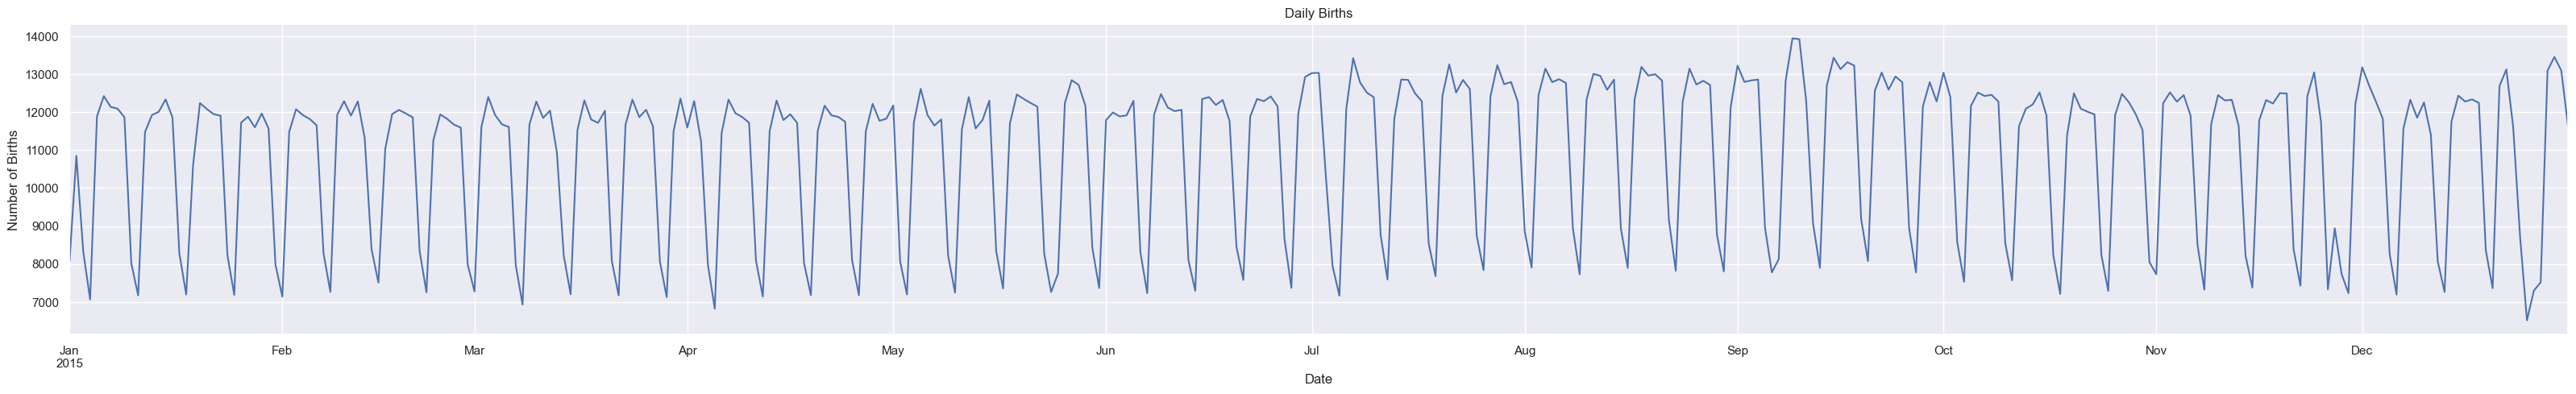

In [16]:
# Plot the data
plt.figure(figsize=(40, 5))
births_only['births'].plot()
plt.title('Daily Births')
plt.xlabel('Date')
plt.ylabel('Number of Births')
plt.grid(True)
plt.show()

In [17]:
births.head()

,births,wday,year,month,day_of_year,day_of_month,day_of_week
date,,,,,,,
2015-01-01,8068,Thu,2015,1,1,1,5
2015-01-02,10850,Fri,2015,1,2,2,6
2015-01-03,8328,Sat,2015,1,3,3,7
2015-01-04,7065,Sun,2015,1,4,4,1
2015-01-05,11892,Mon,2015,1,5,5,2


In [18]:
births.tail()

,births,wday,year,month,day_of_year,day_of_month,day_of_week
date,,,,,,,
2015-12-27,7518,Sun,2015,12,361,27,1
2015-12-28,13100,Mon,2015,12,362,28,2
2015-12-29,13458,Tue,2015,12,363,29,3
2015-12-30,13100,Wed,2015,12,364,30,4
2015-12-31,11608,Thu,2015,12,365,31,5


In [19]:
births.shape

(365, 7)

# EDA and Violinplot for Moths performance

In [20]:
# Replace numerical values with Month Names


births['month']=births['month'].replace(to_replace =[1,2,3,4,5,6,7,8,9,10,11,12],
value =["January","February","March","April","May","June","July","August","September","October","November","December"])

In [21]:
births.head()

,births,wday,year,month,day_of_year,day_of_month,day_of_week
date,,,,,,,
2015-01-01,8068,Thu,2015,January,1,1,5
2015-01-02,10850,Fri,2015,January,2,2,6
2015-01-03,8328,Sat,2015,January,3,3,7
2015-01-04,7065,Sun,2015,January,4,4,1
2015-01-05,11892,Mon,2015,January,5,5,2


## Create violinplots in order to examin the montlhy births distribution

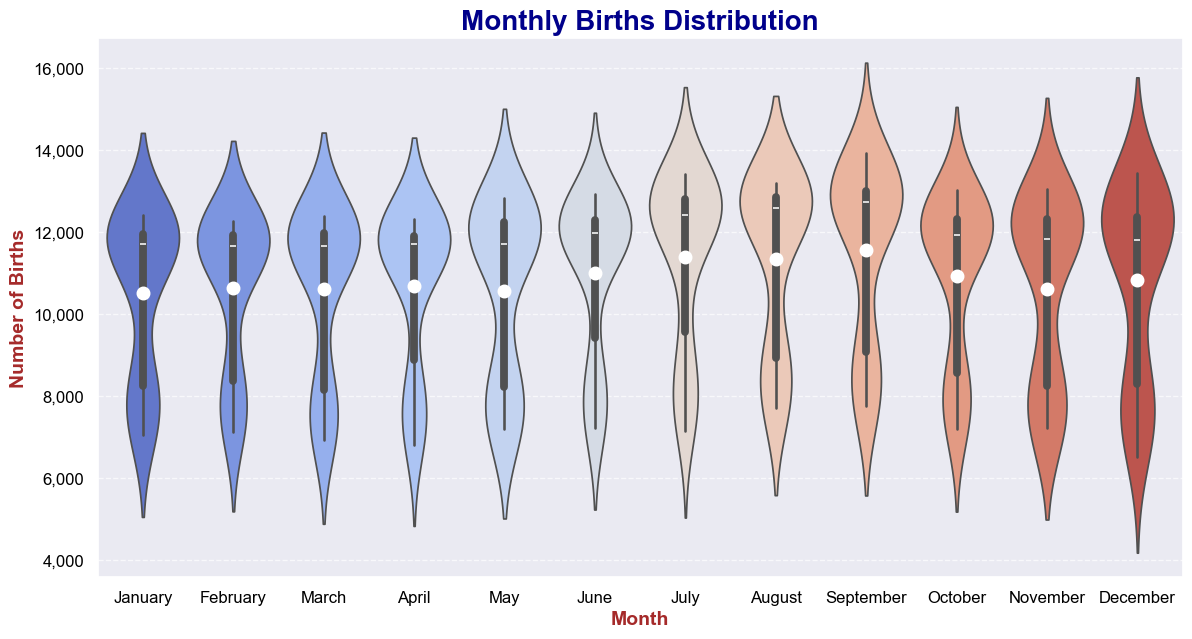

In [22]:
# Create the figure
plt.figure(figsize=(14, 7))

# Violin plot with 'hue' assigned to 'x' to avoid deprecation warning
ax = sns.violinplot(
    data=births, 
    y="births", 
    x="month",
    hue="month",  # Assign x variable to hue
    palette="coolwarm",  
    #inner="quartile",
    legend=False  # Hide duplicate legends
)

# Overlay mean values with white dots
sns.pointplot(
    data=births, 
    y="births", 
    x="month", 
    color="white", 
    markers="o", 
    linestyles="",  # No lines
    errorbar=None,  # No confidence intervals
    dodge=True,
    markersize=8  # Use markersize instead of scale
)

# Customize labels and title
ax.set_title("Monthly Births Distribution", fontweight="bold", fontsize=20, color="darkblue")
ax.set_ylabel("Number of Births", fontweight="bold", fontsize=14, color="brown")
ax.set_xlabel("Month", fontweight="bold", fontsize=14, color="brown")

# Format y-axis ticks with commas for readability
ax.yaxis.set_major_formatter(tkr.FuncFormatter(lambda y, _: f"{int(y):,}"))

# Improve x-axis labels
plt.xticks(fontsize=12, color="black")
plt.yticks(fontsize=12, color="black")

# Add grid lines for better readability
plt.grid(axis="y", linestyle="--", alpha=0.7)

# Show the plot
plt.show()

### How to read the graph:

- Shape (Width of the Violin) → Frequency/Density
    - Wider sections indicate more frequent birth counts for that month.
    - Narrower sections indicate fewer occurrences of those birth counts.
- White Dots → Mean Births per Month
    - Each white dot represents the mean number of births for that month.
- Thick Black Line (Vertical Bar) → Interquartile Range (IQR)
    - Represents the middle 50% of the data (from the 25th to the 75th percentile).
    - If this bar is long, the data is more spread out; if short, births are more concentrated around the median.
- Tails (Extreme Ends) → Min/Max Births
    - The upper and lower edges of each violin show the full range of births.
    - If a tail is long, it suggests more variability or occasional extreme values.

## Insights:
- Births appear fairly stable across months, with some seasonal variation.
- Summer months (June-August) show slightly higher births, as indicated by the white dots.
- December has a slightly narrower spread, suggesting more consistent birth counts.

# Series Decomposition

Time series decomposition is performed to break down a time series into its fundamental components, which helps in understanding the underlying structure and patterns in the data. 

In time series decomposition, the observed time series (yt) is broken down into three components:

- Trend (Tt): The long-term movement or direction in the data.

- Seasonal (St): The repeating short-term cycles or patterns.

- Residual (Rt): The remaining irregular fluctuations after removing the trend and seasonal components.

The choice between an additive or multiplicative model depends on how these components interact with each other in the data.

- If the seasonal fluctuations grow or shrink over time, we use a multiplicative model.
- If the seasonal fluctuations are constant, we use an additive model.

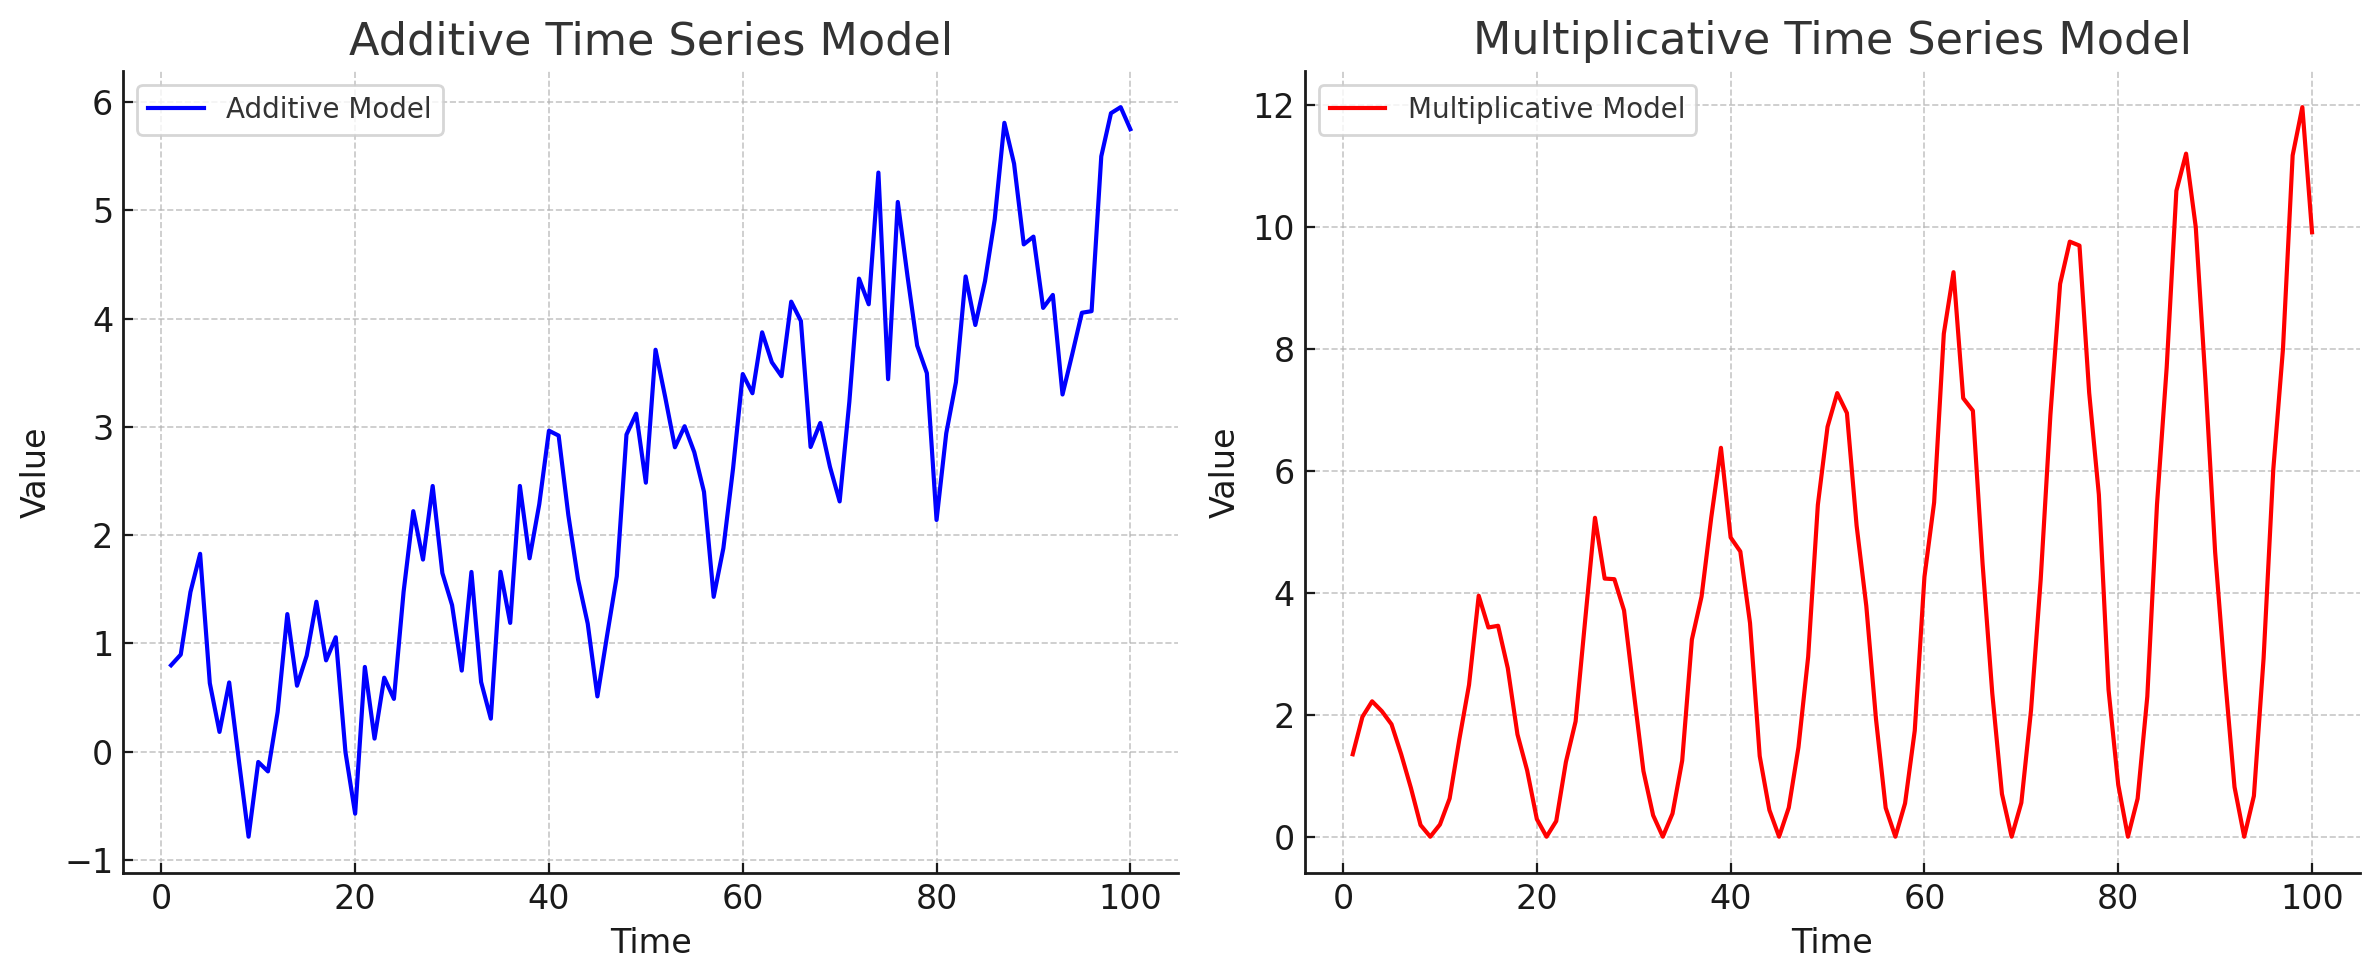

### statsmodels.tsa.seasonal.seasonal_decompose
- The requirement that "x must contain 2 complete cycles" means that my time series data should include at least two full periods of the seasonal component I am trying to analyze.
- For weekly seasonality, I have 52 weeks in a year, which is more than 2 complete cycles.
- For monthly seasonality, I have 12 months, which is also more than 2 complete cycles.


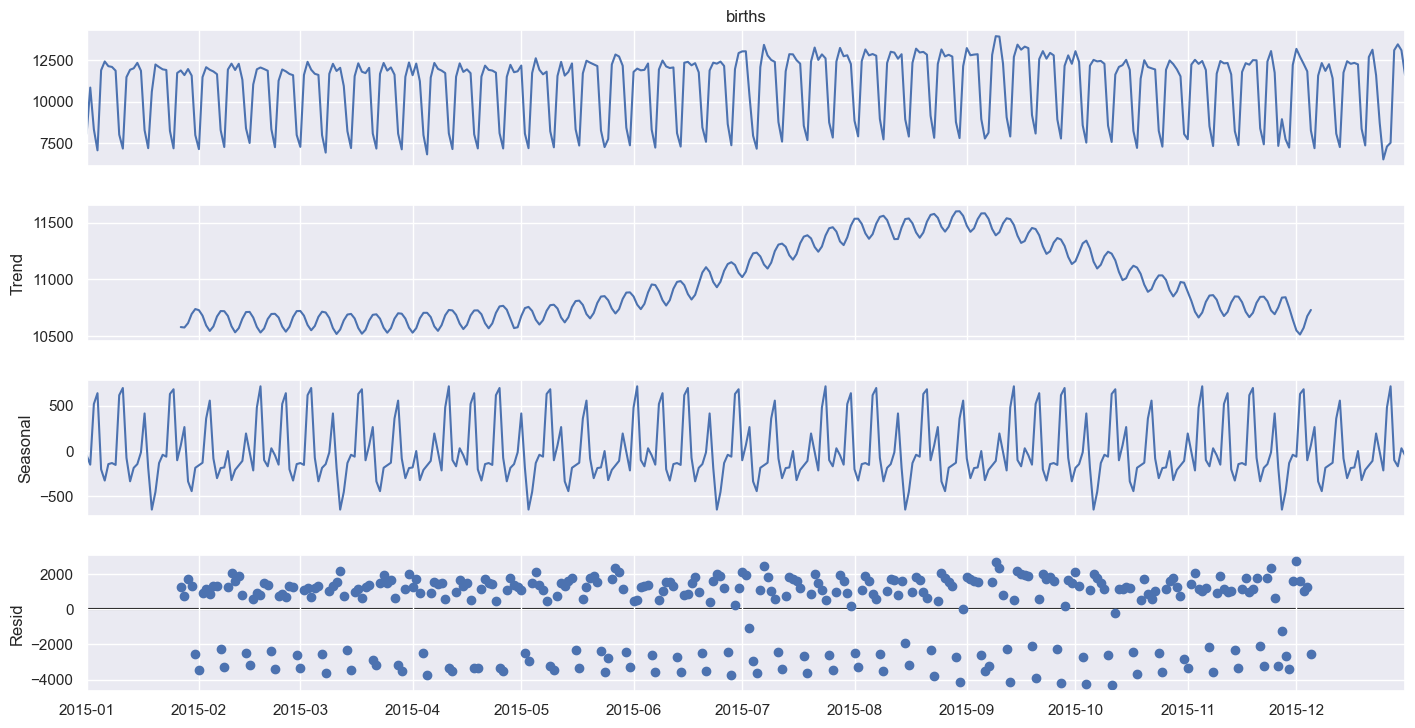

In [23]:
# Perform seasonal decomposition by checking weekly seasonality
decomposition = sm.tsa.seasonal_decompose(births['births'], model='additive', period=52)

# Plot the decomposition components
fig = decomposition.plot()

# Set the figure size
fig.set_size_inches(16, 8)  # Adjust width and height as needed

plt.show()

1. Original Data (Top Plot - "births")
- x: date, y: number of births
- The overall trend appears to be increasing at certain points and decreasing at others.

2. Trend Component (Second Plot - "Trend")
- The trend line shows an upward movement in the middle of the year, followed by a downward trend towards the end.
- This indicates that births may follow a general increasing and decreasing pattern over time.
- There is no strict stationarity since the trend is not constant.

3. Seasonal Component (Third Plot - "Seasonal")

- It is not clear if the pattern is repeated.
- Since I used period=52, this suggests that births might exhibit a weekly seasonality effect.


4. Residual Component (Bottom Plot - "Resid")
- In time series decomposition, residuals represent the portion of the time series that remains after removing the trend and seasonal components. 
- They capture the unexplained or irregular part of the data that cannot be attributed to the systematic patterns (trend and seasonality).
- For an additive model, the decomposition is: yt = Tt + St + Rt.

    ​- The residuals are calculated as: Rt = St + Tt - yt.
- Residuals (random noise) should ideally be randomly scattered around zero with no clear pattern.
- Here, the spread of residuals seems wider at certain points, which might suggest some heteroscedasticity (variance changes over time).

Conclusions:
It is not clear if the data are stationary. Further analysis must be done. A trend seems like to exists.

# Check Stationarity (Plot and Dickey-Fuller Test)

- In order a timeseires to be more easily forecasted, it should be stationary.
- In order a series to be stationary it should not be time dependent and it should hav esteady mean and std.
- Also the Dickey-Fuller Test shows all the necessary values in order to judge whether or not we have a stationary series.

## Dickey-Fuller Test:
- Null Hypothesis (H₀): The time series has a unit root → It is non-stationary (i.e., it has some trend or autocorrelation).
- Alternative Hypothesis (H₁): The time series does not have a unit root → It is stationary (i.e., the statistical properties like mean and variance remain constant over time).

If the p-value is low (< 0.05) and the test statistic is smaller than the critical values, we reject H₀ and conclude that the series is stationary.

This function, test_stationarity(), is designed to assess whether a time series is stationary by:

- Plotting rolling statistics (mean & standard deviation)
- Running the Augmented Dickey-Fuller (ADF) test and printing its results

## Rolling Statistics

Instead of computing a single statistic over an entire set of data, we compute a rolling statistic against a subset, or window, of that data, and we adjust the window with each new data point we encounter.

In [24]:
# Function for Stationarity
# Plot and Dickey-Fuller Test

def test_stationarity(timeseries): #The function takes in a time series as input.
    #Determing rolling statistics
    MA = timeseries.rolling(window=7).mean() # Size of the moving window: window size of 7 means it averages over the last 7 data points, weekly.
    MSTD = timeseries.rolling(window=7).std() 

    #Plot rolling statistics:
    plt.figure(figsize=(15,5))
    orig = plt.plot(timeseries, color='blue',label='Original') #original data
    mean = plt.plot(MA, color='red', label='Rolling Mean') # Moving Average
    std = plt.plot(MSTD, color='black', label = 'Rolling Std') # Rolling Standard Deviation
    plt.legend(loc='best')
    plt.title('Rolling Mean & Standard Deviation')
    plt.show(block=False)

    #Perform Dickey-Fuller test:
    print('Results of Dickey-Fuller Test:')
    #The Augmented Dickey-Fuller (ADF) test is performed using the adfuller() function from statsmodels.tsa.stattools.
    dftest = adfuller(timeseries, autolag='AIC') # autolag='AIC' automatically selects the best lag based on the Akaike Information Criterion (AIC).
    dfoutput = pd.Series(dftest[0:4], index=['Test Statistic','p-value','#Lags Used','Number of Observations Used'])
    for key,value in dftest[4].items():
        dfoutput['Critical Value (%s)'%key] = value
    print(dfoutput)

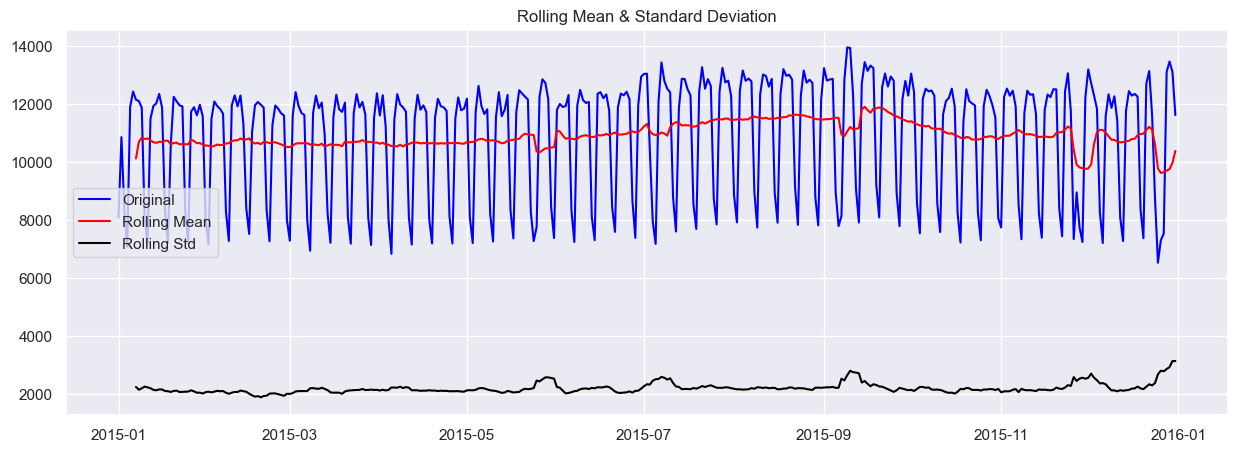

Results of Dickey-Fuller Test:
Test Statistic                  -1.601399
p-value                          0.482890
#Lags Used                      14.000000
Number of Observations Used    350.000000
Critical Value (1%)             -3.449173
Critical Value (5%)             -2.869833
Critical Value (10%)            -2.571188
dtype: float64


In [25]:
# Use function

test_stationarity(births['births'])

It is observed that we do not have a stationary series.


1) The p-value (0.4829) is much greater than the common significance levels (0.01, 0.05, or 0.10), further confirming that we cannot reject the null hypothesis.

2) The test statistic (-1.6014) is higher than all the critical values (-3.449 at 1%, -2.869 at 5%, and -2.571 at 10%). This means we fail to reject the null hypothesis (H₀: The series has a unit root, meaning it is non-stationary).

3) From rolling statistics rolling mean and std seem  in most of the days kind of constant with some exceptions.



# Transform our timeseries to stationary

1. First-order differencing: df.diff() to remove the trend.

In [26]:
births_only.head()

,births
date,
2015-01-01,8068
2015-01-02,10850
2015-01-03,8328
2015-01-04,7065
2015-01-05,11892


In [27]:
# Take difference in order to create a stationary series

births_diff = births_only.diff()


In [28]:
births_diff.head()

,births
date,
2015-01-01,NaN
2015-01-02,2782.0
2015-01-03,-2522.0
2015-01-04,-1263.0
2015-01-05,4827.0


In [29]:
births_diff = births_diff.dropna()

In [30]:
births_diff.head()

,births
date,
2015-01-02,2782.0
2015-01-03,-2522.0
2015-01-04,-1263.0
2015-01-05,4827.0
2015-01-06,533.0


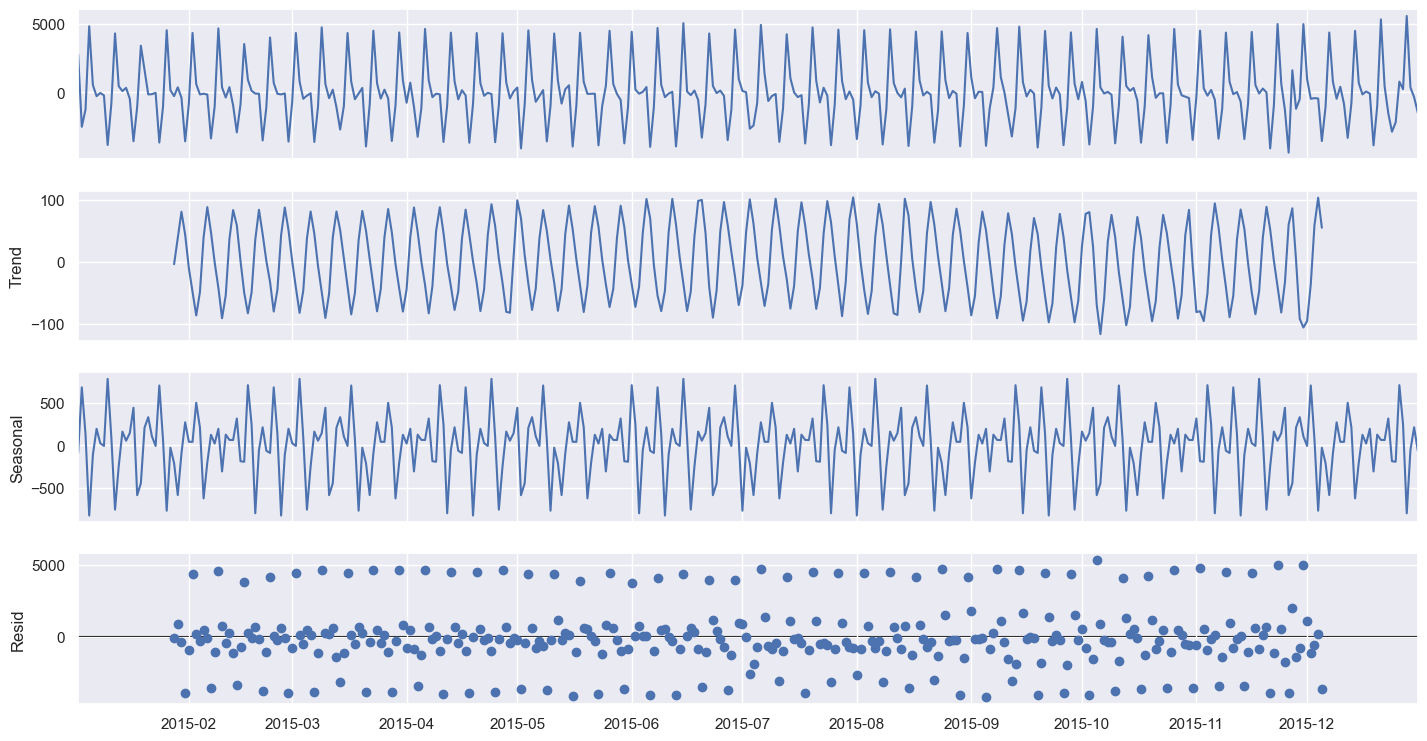

In [31]:
#Plot again the decomposition to check the diffenced series

decomposition_2 = sm.tsa.seasonal_decompose(births_diff, period=52)

# Plot the decomposition components
fig_2 = decomposition_2.plot()

# Set the figure size
fig_2.set_size_inches(16, 8)  # Adjust width and height as needed

plt.show()

1. Observed Component (First Plot)
- The original series is now more stationary, with fluctuations centered around zero.

2. Trend Component (Second Plot)
- There is not a specific trend.

3. Seasonal Component (Third Plot)
- Seasonality still is not clear if exists.

4. Residual Component (Fourth Plot)
- Ideally, residuals should look like white noise (randomly scattered points with no pattern).
- My residuals still show some variation and structure, suggesting the model might still capture some patterns.

## Check Stationarity again

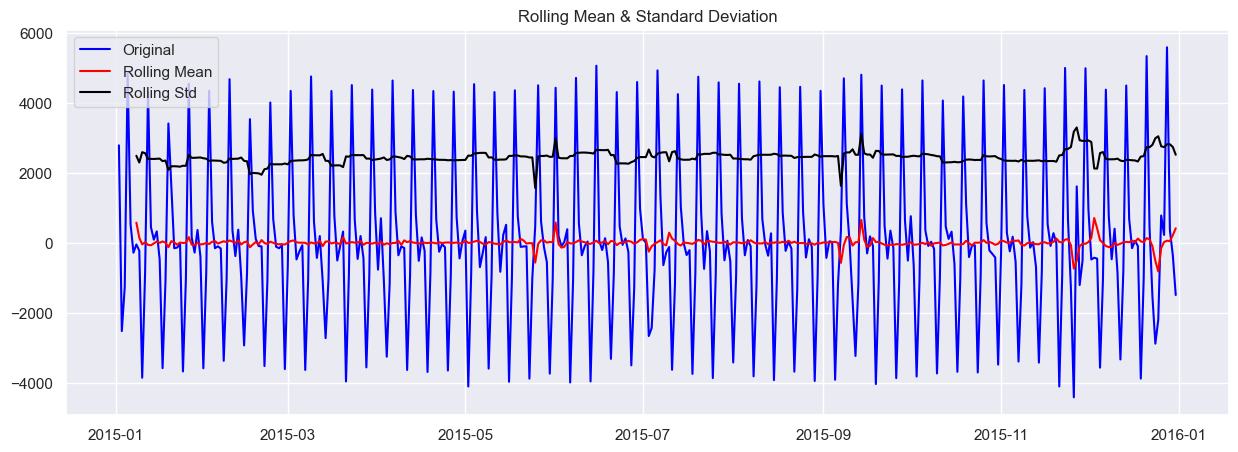

Results of Dickey-Fuller Test:
Test Statistic                -9.653695e+00
p-value                        1.412516e-16
#Lags Used                     1.300000e+01
Number of Observations Used    3.500000e+02
Critical Value (1%)           -3.449173e+00
Critical Value (5%)           -2.869833e+00
Critical Value (10%)          -2.571188e+00
dtype: float64


In [32]:
test_stationarity(births_diff)

Time series is now stationary:
- Mean seems stable over time and around zero now. Std seems overall stable too, with some exceptions again. No trend seems to exists.
- Test Statistic: -9.65 (way lower than all critical values)
- p-value: 1.41e-16 (<< 0.05, meaning we reject H0)

# 1. Create first Naive Model (what happened yesterday will happen tomorrow)

In [33]:
births_diff

,births
date,
2015-01-02,2782.0
2015-01-03,-2522.0
2015-01-04,-1263.0
2015-01-05,4827.0
2015-01-06,533.0
...,...
2015-12-27,224.0
2015-12-28,5582.0
2015-12-29,358.0


In [34]:
#Build a Naive Baseline Model (what happened yesterday will happen tomorrow)

naive_model=births_diff
naive_model=pd.concat([naive_model,naive_model.shift(1)],axis=1)
naive_model.columns=["Actual Births","Predicted Births"]


In [35]:
naive_model.head()

,Actual Births,Predicted Births
date,,
2015-01-02,2782.0,NaN
2015-01-03,-2522.0,2782.0
2015-01-04,-1263.0,-2522.0
2015-01-05,4827.0,-1263.0
2015-01-06,533.0,4827.0


In [36]:
naive_model.dropna(inplace=True)

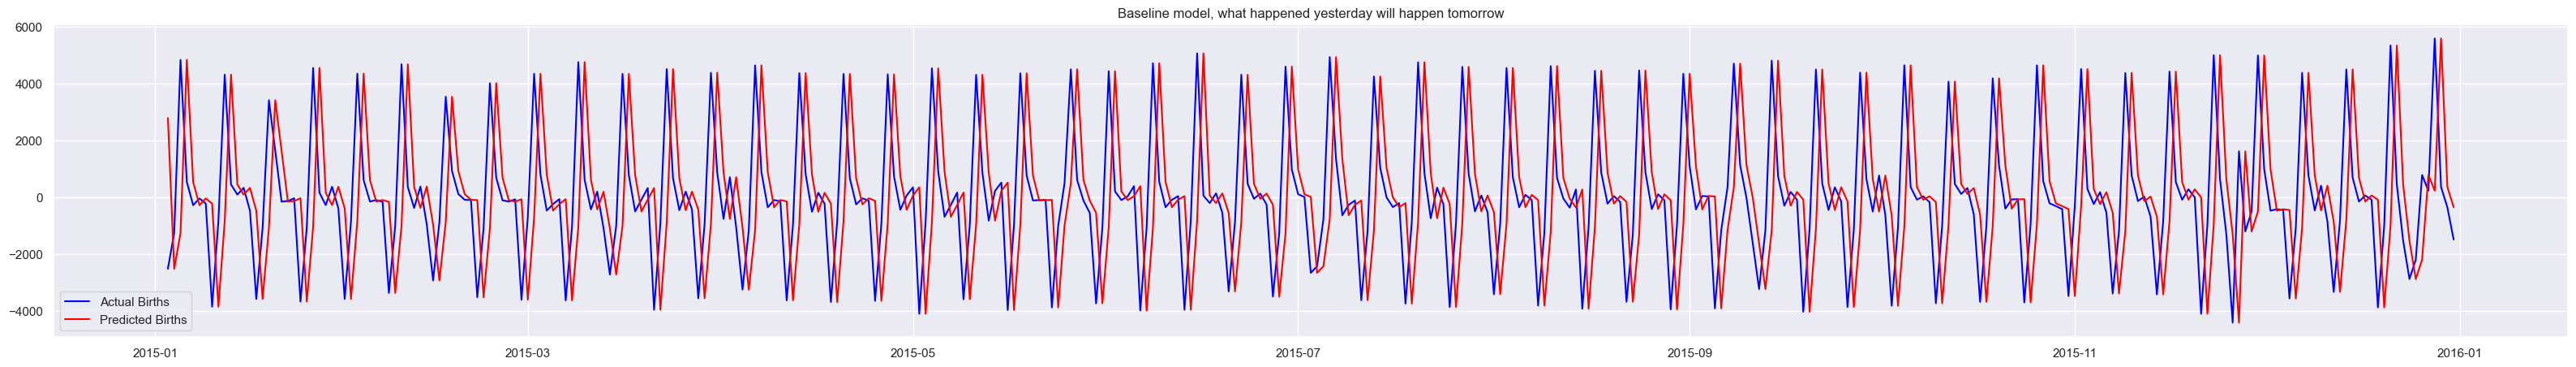

In [37]:
#Plot rolling statistics:

plt.figure(figsize=(40,5))
plt.plot(naive_model["Actual Births"], color='blue',label='Actual Births')
plt.plot(naive_model["Predicted Births"], color='red', label='Predicted Births')

plt.legend(loc='best')
plt.title('Baseline model, what happened yesterday will happen tomorrow')
plt.show(block=False)

In [38]:
# Check MSE for this first model
birth_error=mean_squared_error(naive_model["Actual Births"],naive_model["Predicted Births"])
birth_error

9421121.482093664

In [39]:
#MSE is not easy to interpretable so we will take the square root that will give us the actual birth value.
np.sqrt(birth_error)

3069.384544512737

Not good results!

# 2. ARIMA - Autoregressive (p) integrated (d) moving average (q) Model 

In order to fit an ARIMA model we should find the parameters: p, d and q.

Previously in order to make our series stationary, we took the difference with previous day, so we have d = 1 and the data we will use for train and test will be the original not stationary ones because they will get stationary by d=1.

So, we have to select the remaining components p and q.

We will do it by generating and examining the ACF and PACF plots and the significance of the time lags.

## Selecting Parameters p and q through ACF and PACF plots

ACF Plot:
- The ACF plot shows the correlation between the time series and its lagged values, including indirect correlations.
- It helps in identifying the order of the moving average part (q) of the ARIMA model.

PACF Plot:
- The PACF plot shows the correlation between the time series and its lagged values, excluding the influence of intermediate lags.
- It helps in identifying the order of the autoregressive part (p) of the ARIMA model.

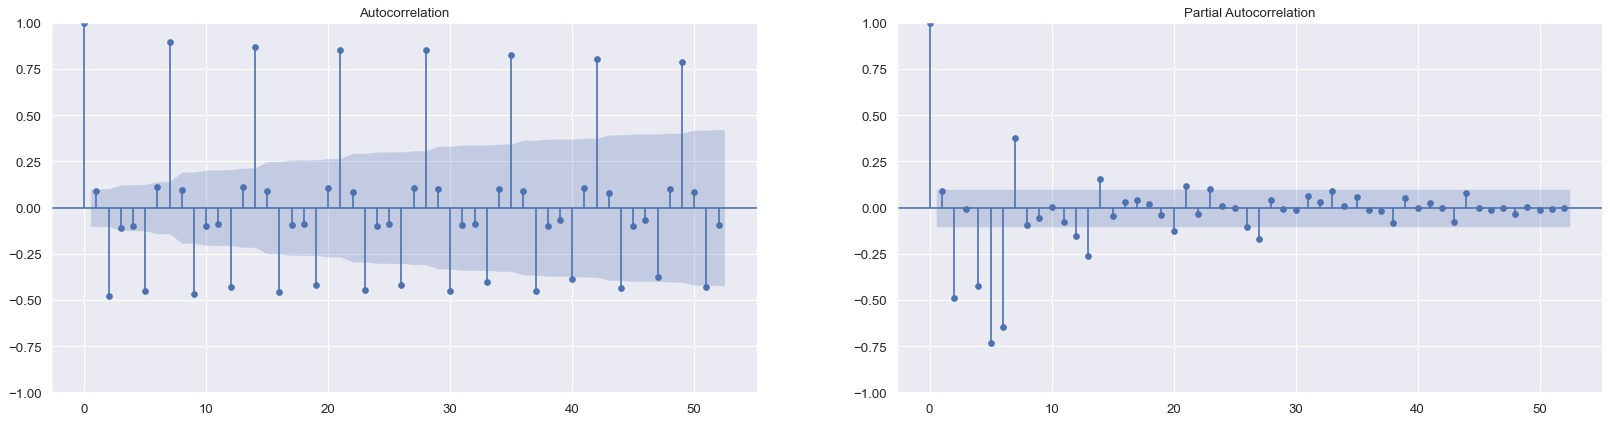

In [40]:
# Draw Plot
fig, (ax1, ax2) = plt.subplots(1, 2,figsize=(25,6), dpi= 80)
plot_acf(births_diff, ax=ax1, lags=52)
plot_pacf(births_diff, ax=ax2, lags=52)

# Decorate
# lighten the borders
ax1.spines["top"].set_alpha(.3); ax2.spines["top"].set_alpha(.3)
ax1.spines["bottom"].set_alpha(.3); ax2.spines["bottom"].set_alpha(.3)
ax1.spines["right"].set_alpha(.3); ax2.spines["right"].set_alpha(.3)
ax1.spines["left"].set_alpha(.3); ax2.spines["left"].set_alpha(.3)

# font size of tick labels
ax1.tick_params(axis='both', labelsize=12)
ax2.tick_params(axis='both', labelsize=12)
plt.show()

- For both the ACF and PACF graphs, I will focus only on the lags where the correlation values exceed the critical limits, as these are statistically significant.

- I will experiment with different combinations of p and q (while keeping d=1 for differencing) based on the significant lags identified in the ACF and PACF plots. 

- To evaluate the performance of these combinations, I will use Mean Absolute Error (MAE) and Mean Absolute Percentage Error (MAPE) as error metrics. 



# Split Dataset into training and test

In [41]:
births_only.shape

(365, 1)

In [42]:
births_only

,births
date,
2015-01-01,8068
2015-01-02,10850
2015-01-03,8328
2015-01-04,7065
2015-01-05,11892
...,...
2015-12-27,7518
2015-12-28,13100
2015-12-29,13458


<function matplotlib.pyplot.show(close=None, block=None)>

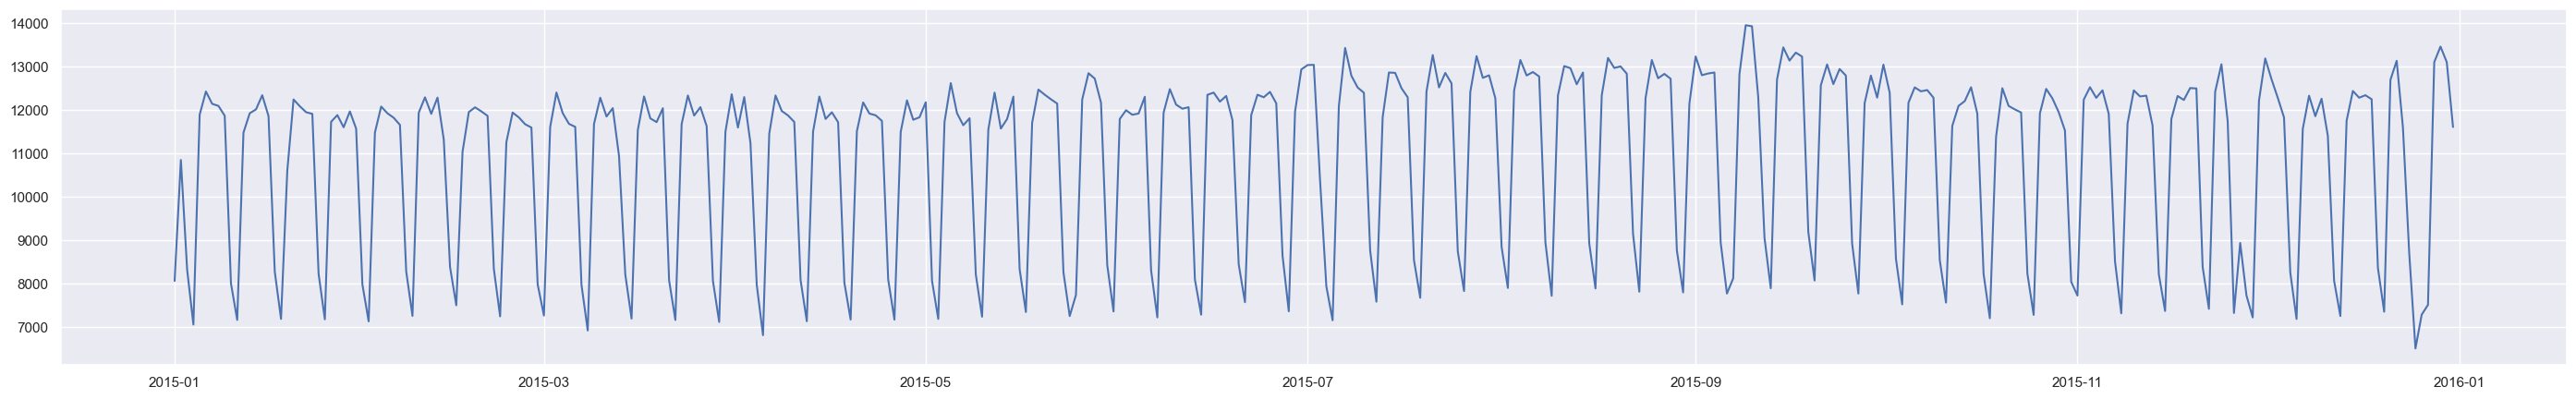

In [43]:

plt.figure(figsize=(35,5))
plt.plot(births_only)
plt.show

In [44]:
train_births = births_only[0:330]
test_births = births_only[330:]


In [45]:
train_births.shape

(330, 1)

In [46]:
test_births.shape

(35, 1)

<function matplotlib.pyplot.show(close=None, block=None)>

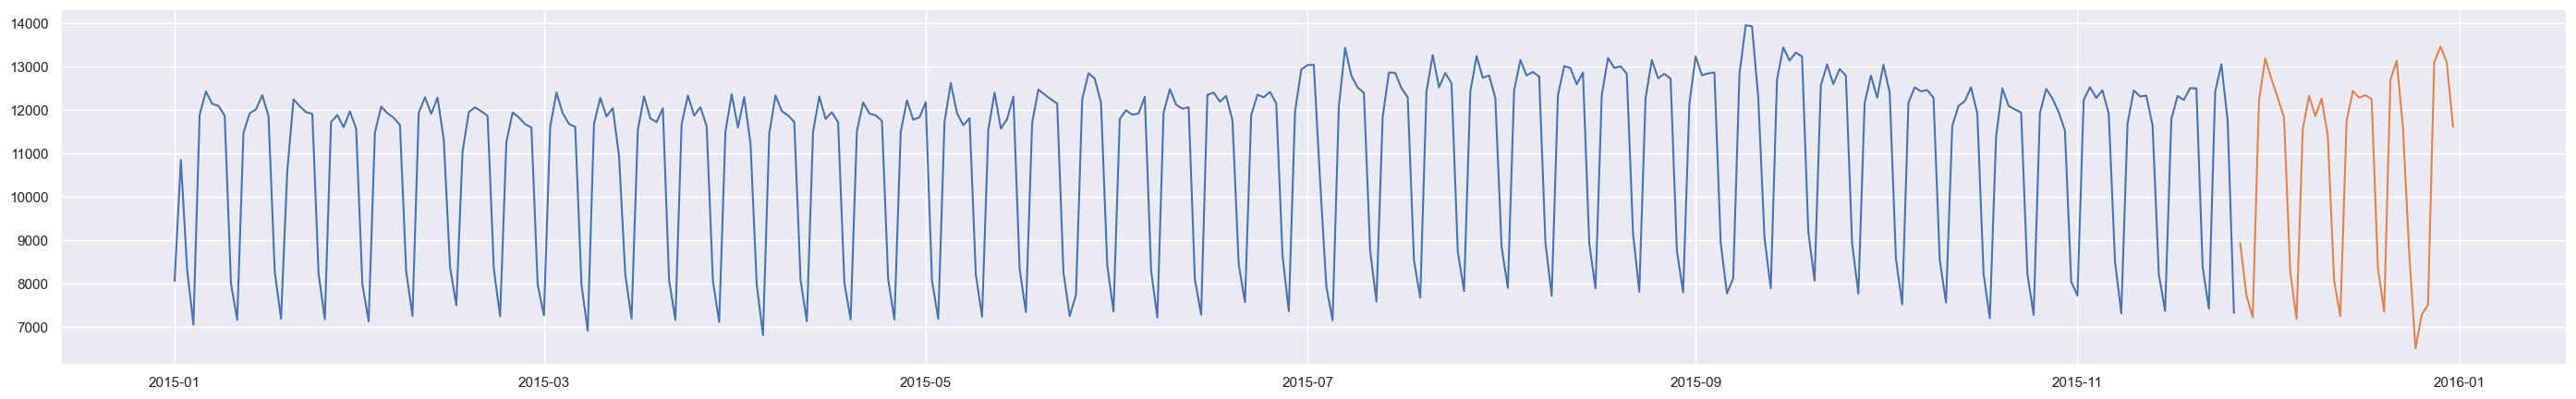

In [47]:
# Creat timeseries plot


plt.figure(figsize=(35,5))
plt.plot(train_births)
plt.plot(test_births)
plt.show

# 1st Arima Model with values from plots

let's try with p = 3, d = 1 amd q = 3

In [48]:
# Building 1st ARIMA Model

arima_1 = pm.arima.ARIMA(order=(3,1,3))
arima_1.fit(train_births)

ARIMA(order=(3, 1, 3))

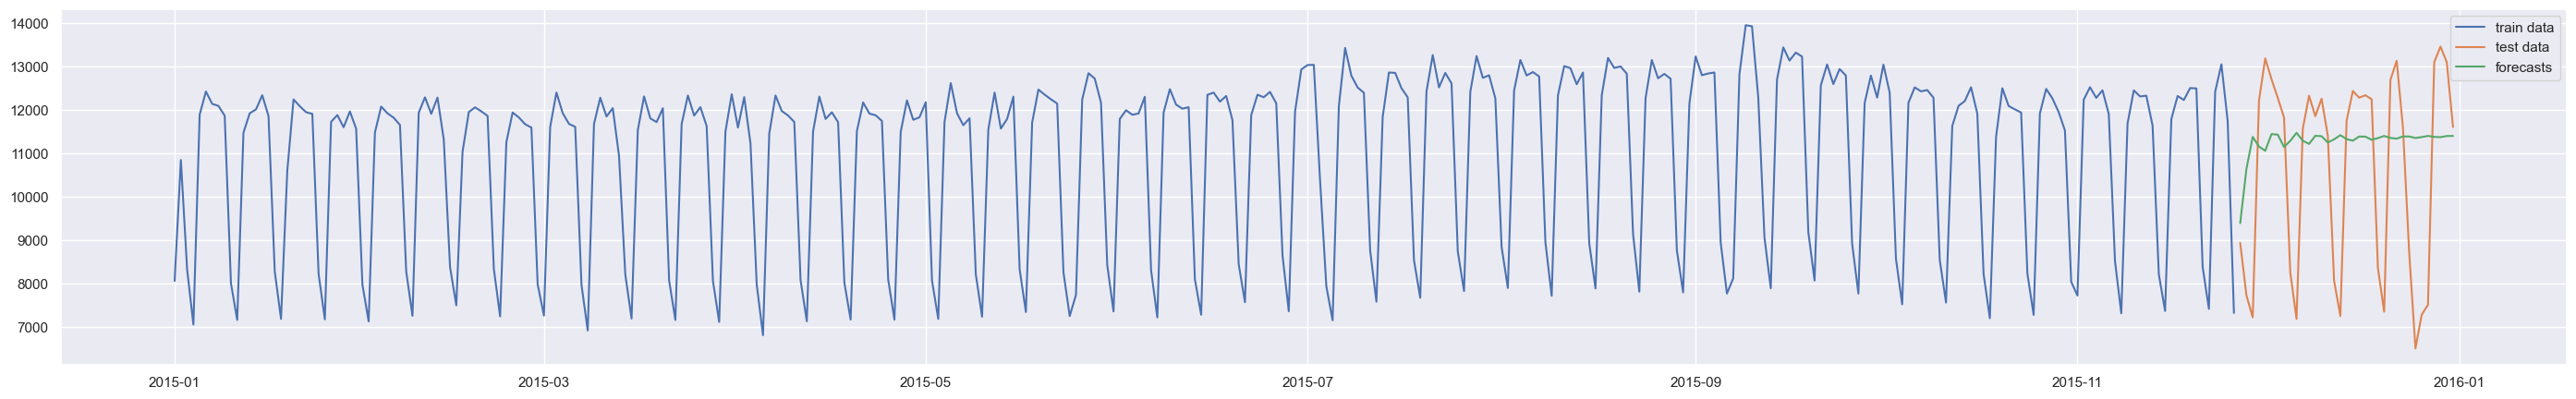

In [49]:
# Inspect Predictions

y_pred_1 = pd.DataFrame(
    arima_1.predict(n_periods=len(test_births)),  # Ensure correct length
    index=test_births.index,  # Align index with test set
    columns=['pred']
)
plt.figure(figsize=(35,5))
plt.plot(train_births, label='train data')
plt.plot(test_births, label='test data')
plt.plot(y_pred_1, label='forecasts')
plt.legend()
plt.show()

In [50]:
print(f'mean absolute error: {round(mean_absolute_error(test_births, y_pred_1), 2)} \n')

mean absolute error: 1912.79 



# 2nd Arima Model

let's try with p = 5, d=1, q =5

In [51]:
# Building 2nd ARIMA Model

arima_2 = pm.arima.ARIMA(order=(5,1,5))
arima_2.fit(train_births)

ARIMA(order=(5, 1, 5))

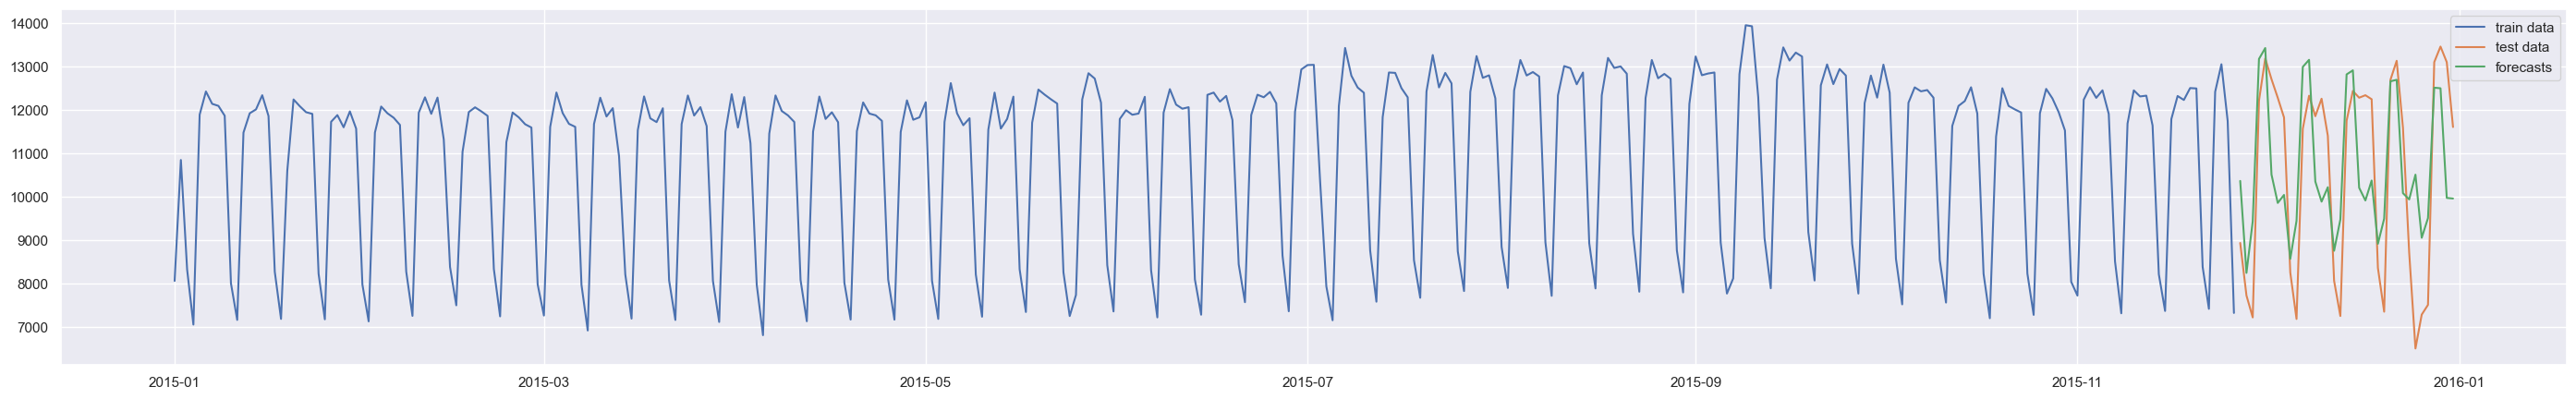

In [52]:
# Inspect Predictions


y_pred_2 = pd.DataFrame(
    arima_2.predict(n_periods=len(test_births)),  # Ensure correct length
    index=test_births.index,  # Align index with test set
    columns=['pred']
)
plt.figure(figsize=(35,5))
plt.plot(train_births, label='train data')
plt.plot(test_births, label='test data')
plt.plot(y_pred_2, label='forecasts')
plt.legend()
plt.show()

In [53]:
print(f'mean absolute error: {round(mean_absolute_error(test_births, y_pred_2), 2)} \n')

mean absolute error: 1497.12 



# 3rd Arima Model

In [54]:
arima_3 = pm.arima.ARIMA(order=(13,1,19))
arima_3.fit(train_births)

ARIMA(order=(13, 1, 19))

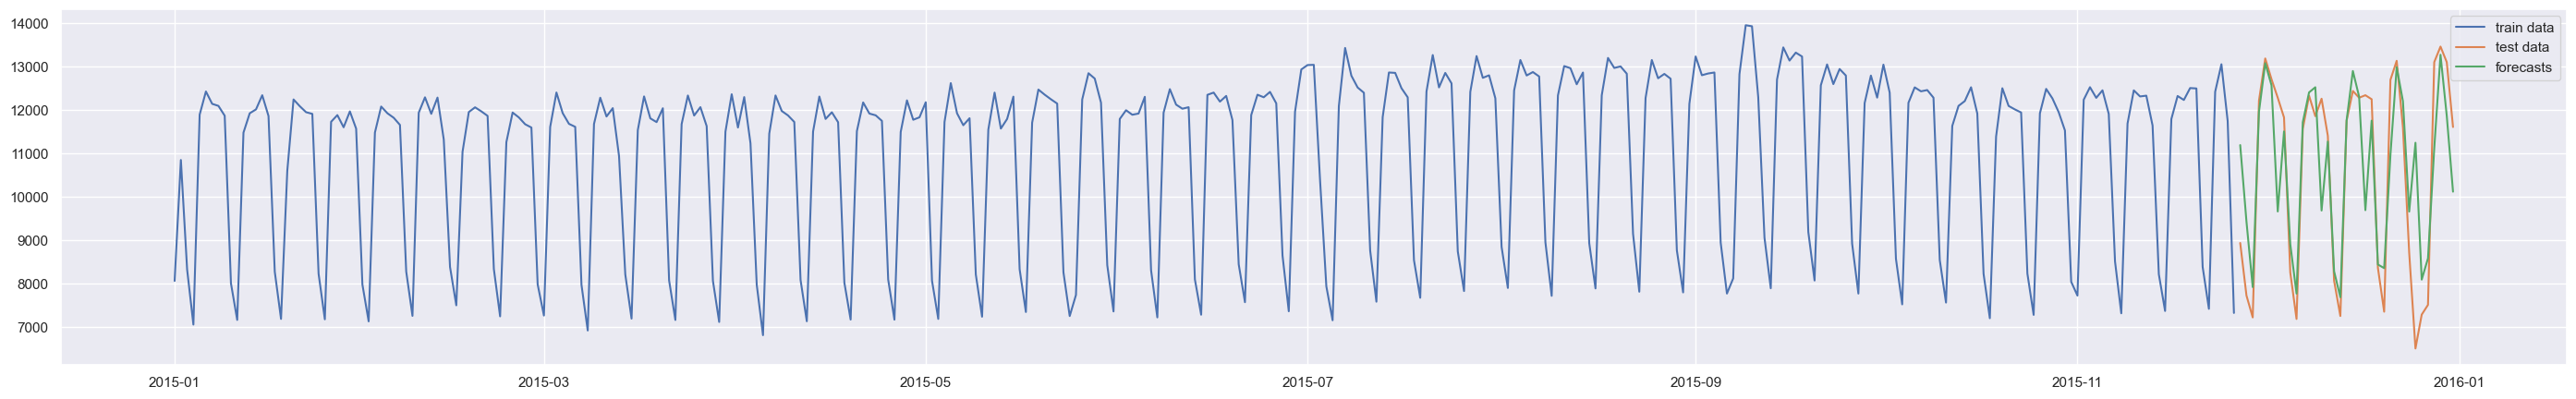

In [55]:
# Inspect Predictions


y_pred_3 = pd.DataFrame(
    arima_3.predict(n_periods=len(test_births)),  # Ensure correct length
    index=test_births.index,  # Align index with test set
    columns=['pred']
)
plt.figure(figsize=(35,5))
plt.plot(train_births, label='train data')
plt.plot(test_births, label='test data')
plt.plot(y_pred_3, label='forecasts')
plt.legend()
plt.show()

In [56]:
print(f'mean absolute percentage error: {round(mean_absolute_percentage_error(test_births, y_pred_3), 2)} \n')
print(f'mean absolute error: {round(mean_absolute_error(test_births, y_pred_3), 2)} \n')

mean absolute percentage error: 0.1 

mean absolute error: 948.76 



# 4th Model - Using SARIMA through Autoarima

In [57]:
# Fit stepwise auto-ARIMA with seasonal order
model = pm.auto_arima(train_births, start_p=1, start_q=1, max_p=30, max_q=30, # start and end p and q
                      test = 'adf', # use adftest to find optimal 'd'
                      seasonal=True, # We have Seasonality
                      d=None, D=None,  # let model determine 'd' we have used 1, let's see if it is the same
                      trace=True, m=7,   # trace to keep record of scores, m ->frequency of series (weekly)
                      error_action='ignore',
                      suppress_warnings=True,
                      stepwise=True)

Performing stepwise search to minimize aic
 ARIMA(1,1,1)(1,0,1)[7] intercept   : AIC=inf, Time=1.00 sec
 ARIMA(0,1,0)(0,0,0)[7] intercept   : AIC=6020.732, Time=0.01 sec
 ARIMA(1,1,0)(1,0,0)[7] intercept   : AIC=5396.839, Time=0.36 sec
 ARIMA(0,1,1)(0,0,1)[7] intercept   : AIC=5781.721, Time=0.22 sec
 ARIMA(0,1,0)(0,0,0)[7]             : AIC=6018.734, Time=0.02 sec
 ARIMA(1,1,0)(0,0,0)[7] intercept   : AIC=6019.516, Time=0.02 sec
 ARIMA(1,1,0)(2,0,0)[7] intercept   : AIC=inf, Time=0.56 sec
 ARIMA(1,1,0)(1,0,1)[7] intercept   : AIC=inf, Time=0.66 sec
 ARIMA(1,1,0)(0,0,1)[7] intercept   : AIC=5782.111, Time=0.23 sec
 ARIMA(1,1,0)(2,0,1)[7] intercept   : AIC=inf, Time=1.16 sec
 ARIMA(0,1,0)(1,0,0)[7] intercept   : AIC=5408.855, Time=0.28 sec
 ARIMA(2,1,0)(1,0,0)[7] intercept   : AIC=5377.731, Time=0.56 sec
 ARIMA(2,1,0)(0,0,0)[7] intercept   : AIC=5920.946, Time=0.05 sec
 ARIMA(2,1,0)(2,0,0)[7] intercept   : AIC=inf, Time=nan sec
 ARIMA(2,1,0)(1,0,1)[7] intercept   : AIC=5280.742, Time=0.

- The first components are p=2 d=1 q=0.
- The second parantheseis are the Seasonal components 
- The last element 7, indicates the seasonal cycle (weekly data=7)

In [58]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                      
===========================================================================================
Dep. Variable:                                   y   No. Observations:                  330
Model:             SARIMAX(2, 1, 0)x(1, 0, [1], 7)   Log Likelihood               -2634.371
Date:                             Mon, 17 Mar 2025   AIC                           5280.742
Time:                                     13:19:08   BIC                           5303.519
Sample:                                 01-01-2015   HQIC                          5289.828
                                      - 11-26-2015                                         
Covariance Type:                               opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     -6.0280      6.396     -0.943      0.346     -18.563       6.507
ar.L1         -0.2412      0.023    -10.689      0.000      -0.285      -0.197
ar.L2         -0.3011      0.031     -9.585      0.000      -0.363      -0.240
ar.S.L7        0.9733      0.006    164.361      0.000       0.962       0.985
ma.S.L7       -0.6215      0.031    -19.788      0.000      -0.683      -0.560
sigma2      4.423e+05   1.15e+04     38.620      0.000     4.2e+05    4.65e+05
===================================================================================
Ljung-Box (L1) (Q):                   0.66   Jarque-Bera (JB):              2286.68
Prob(Q):                              0.41   Prob(JB):                         0.00
Heteroskedasticity (H):               1.42   Skew:                            -1.48
Prob(H) (two-sided):                  0.07   Kurtosis:                        15.57
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

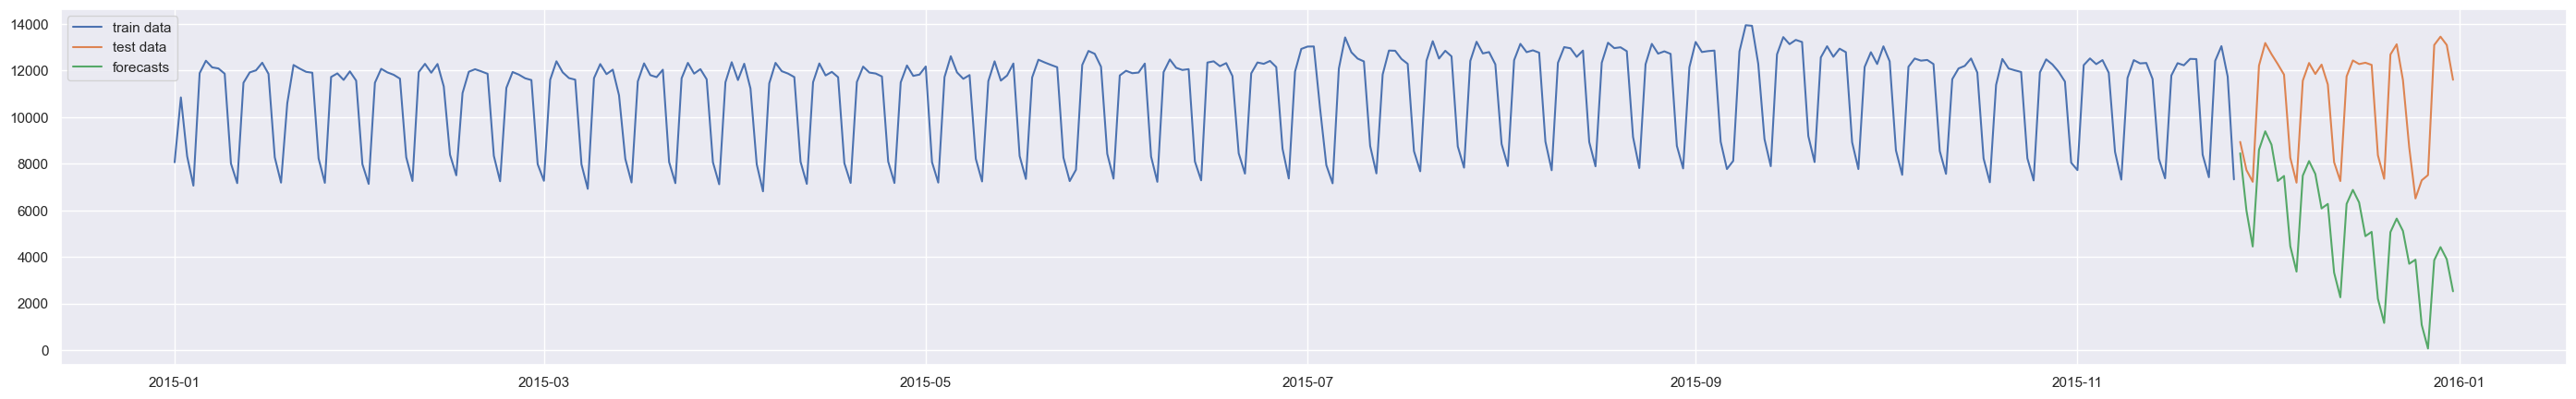

In [59]:

y_pred_4 = pd.DataFrame(
    model.predict(n_periods=len(test_births)),  # Ensure correct length
    index=test_births.index,  # Align index with test set
    columns=['pred']
)
plt.figure(figsize=(35,5))
plt.plot(train_births, label='train data')
plt.plot(test_births, label='test data')
plt.plot(y_pred_4, label='forecasts')
plt.legend()
plt.show()

In [60]:

print(f'mean absolute error: {round(mean_absolute_error(test_births, y_pred_4), 2)} \n')

mean absolute error: 5433.03 



# Conclusion

Births range from 6,000 to 13,000

## Best Model
Model 3 - ARIMA (p =13, d=1, q=19) has the lowest MAE (948.76) 